# Fender Capacity Utilisation — Wind Sea vs Swell

Fender analogue of the mooring MBL utilisation comparison (`08_DAF_Swells_vs_Steepness.ipynb`),
restricted to the **governing fender** (the one carrying the maximum peak force) at each condition.

Utilisation is measured against the fender **capacity at full compression** — the force at the end
of the SIMA spring curve, 2.5 m / **5053 kN** — *not* against an MBL. Because the fenders are too
weak for the severe sea states, many conditions exceed 100% (the fender bottoms out: deflection is
capped at 2.5 m while the reaction keeps rising). That exceedance is the point of interest here.

Colour scale is the same 0–100% RdYlGn used for the mooring MBL heatmaps; conditions above 100%
saturate solid red while the true percentage is printed in each cell / marker. Wind-sea conditions
follow the wave-steepness lines; swells sit on the long-period $H_s$–$T_p$ grid. Headings: 0°, 45°,
90°, 135°, 180°.

In [ ]:
import os, glob
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from pathlib import Path

# Resolve this notebook's folder (works in VS Code and standard Jupyter)
NOTEBOOK_DIR = Path(globals().get('__vsc_ipynb_file__', Path.cwd() / '_')).parent
os.chdir(NOTEBOOK_DIR)
import sys
sys.path.insert(0, str(NOTEBOOK_DIR))
from thesis_style import apply, full, save
apply()
print(f'Working directory: {Path.cwd()}')

In [2]:
g = 9.81
TRANSIENT_S, DT = 400, 0.5
TRANSIENT_IDX = int(TRANSIENT_S / DT)

# Fender capacity = reaction at full compression (2.5 m), the end of the SIMA spring curve.
# Utilisation is taken against THIS value, not an MBL. Anything above 100% has bottomed out:
# deflection is capped at 2.5 m and the reaction keeps rising (fender too weak for that sea state).
FENDER_CAP_KN = 5053.0

HEADINGS       = ['0deg', '45deg', '90deg', '135deg', '180deg']
HEADING_LABELS = {'0deg': '0°', '45deg': '45°', '90deg': '90°',
                  '135deg': '135°', '180deg': '180°'}
FENDER_ELEMS   = [f'Fender{i}' for i in range(1, 7)]

SWELL_DYNAMIC = '{h}/Swells/DynamicResults_swells.h5'

_B = 'BerthedTanker_Catenary'
HS_VALUES = np.linspace(0.5, 3.5, 10)

LINES = {
    'HL7':  {'n':  7, 'base': f'{_B}/Run1',  'label': '$H/\\lambda = 1/7$',  'lw': 7.0, 'ms': 180, 'n_cond': 9},
    'HL9':  {'n':  9, 'base': f'{_B}/Run2',  'label': '$H/\\lambda = 1/9$',  'lw': 6.5, 'ms': 160, 'n_cond': 9},
    'HL11': {'n': 11, 'base': f'{_B}/Run3',  'label': '$H/\\lambda = 1/11$', 'lw': 6.0, 'ms': 140, 'n_cond': 9},
    'HL13': {'n': 13, 'base': f'{_B}/Run4',  'label': '$H/\\lambda = 1/13$', 'lw': 5.5, 'ms': 120, 'n_cond': 9},
    'HL15': {'n': 15, 'base': f'{_B}/Run5',  'label': '$H/\\lambda = 1/15$', 'lw': 5.0, 'ms': 105, 'n_cond': 9},
    'HL17': {'n': 17, 'base': f'{_B}/Run6',  'label': '$H/\\lambda = 1/17$', 'lw': 4.5, 'ms':  90, 'n_cond': 9},
    'HL19': {'n': 19, 'base': f'{_B}/Run7',  'label': '$H/\\lambda = 1/19$', 'lw': 4.0, 'ms':  75, 'n_cond': 9},
    'HL21': {'n': 21, 'base': f'{_B}/Run8',  'label': '$H/\\lambda = 1/21$', 'lw': 3.5, 'ms':  62, 'n_cond': 9},
    'HL23': {'n': 23, 'base': f'{_B}/Run9',  'label': '$H/\\lambda = 1/23$', 'lw': 3.2, 'ms':  55, 'n_cond': 9},
    'HL25': {'n': 25, 'base': f'{_B}/Run10', 'label': '$H/\\lambda = 1/25$', 'lw': 2.9, 'ms':  48, 'n_cond': 8},
    'HL27': {'n': 27, 'base': f'{_B}/Run11', 'label': '$H/\\lambda = 1/27$', 'lw': 2.6, 'ms':  42, 'n_cond': 7},
    'HL29': {'n': 29, 'base': f'{_B}/Run12', 'label': '$H/\\lambda = 1/29$', 'lw': 2.3, 'ms':  36, 'n_cond': 7},
}

for cfg in LINES.values():
    nc   = cfg['n_cond']
    Hs_v = HS_VALUES[:nc]
    Tp_v = np.sqrt(Hs_v * 2 * np.pi * cfg['n'] / g)
    cfg['cond_params'] = {i+1: (round(float(hs), 2), round(float(tp), 2))
                          for i, (hs, tp) in enumerate(zip(Hs_v, Tp_v))}

# Swell Hs/Tp grid (matches notebooks 06/07/08)
HS_VALS = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
TP_VALS = list(range(8, 21))
cases = pd.DataFrame([(hs, tp) for hs in HS_VALS for tp in TP_VALS], columns=['Hs', 'Tp'])
cases.insert(0, 'condition', cases.index + 1)

VMIN, VMAX = 0, 100  # % of fender capacity (same scale as the mooring MBL heatmaps)
print(f'Fender capacity (2.5 m, full compression): {FENDER_CAP_KN:.0f} kN')

Fender capacity (2.5 m, full compression): 5053 kN


## Wind-sea governing fender — `fender_statistics.csv`

For every (heading, line, condition) the fender with the highest peak dynamic force is selected and
expressed as a percentage of the 5053 kN capacity. `dyn_max_kN` in the CSV is already the maximum
over all seeds.

In [3]:
df_f = pd.read_csv('fender_statistics.csv')

idx = df_f.groupby(['heading', 'line', 'cond_num', 'Hs', 'Tp'])['dyn_max_kN'].idxmax()
ww  = df_f.loc[idx, ['heading', 'line', 'cond_num', 'Hs', 'Tp', 'elem', 'dyn_max_kN']].copy()
ww  = ww.rename(columns={'dyn_max_kN': 'max_force_kN'})
ww['gov_num'] = ww['elem'].str.replace('Fender', '', regex=False)
ww['pct_cap'] = ww['max_force_kN'] / FENDER_CAP_KN * 100.0

print('wind-sea rows:', len(ww))
print(f'max wind-sea utilisation: {ww.pct_cap.max():.1f}%  '
      f'({ww.max_force_kN.max():.0f} kN, '
      f"{ww.loc[ww.pct_cap.idxmax(), 'heading']} {ww.loc[ww.pct_cap.idxmax(), 'line']})")
print(f'conditions over 100% (bottomed): {(ww.pct_cap > 100).sum()} / {len(ww)}')

wind-sea rows: 515
max wind-sea utilisation: 276.3%  (13961 kN, 90deg HL23)
conditions over 100% (bottomed): 12 / 515


## Swell governing fender — direct from HDF5

Swell files store only `TotalForce_FenderX` (no deformation), so the governing fender's peak
dynamic force is read straight from the post-transient time series, same as notebook 06.

In [4]:
def load_swell_fenders(h):
    p = NOTEBOOK_DIR / SWELL_DYNAMIC.format(h=h)
    if not p.exists():
        return None
    recs = []
    with h5py.File(p, 'r') as fd:
        root = list(fd.keys())[0]
        sw   = fd[root]['Swells']
        for k in sorted(sw.keys(), key=lambda x: int(x.rsplit('_', 1)[-1])):
            n = int(k.rsplit('_', 1)[-1])
            try:
                grp = sw[k]['Dynamic']['Tanker']['Positioning system force']
            except KeyError:
                continue
            forces = [(float(np.max(grp[f'TotalForce_{fdr}'][TRANSIENT_IDX:])) / 1e3, fdr)
                      for fdr in FENDER_ELEMS]
            fmax, gov = max(forces, key=lambda x: x[0])
            recs.append({'condition': n, 'max_force_kN': fmax, 'gov_fender': gov})
    df = pd.DataFrame(recs).merge(cases, on='condition', how='left')
    df['gov_num'] = df['gov_fender'].str.replace('Fender', '', regex=False)
    df['pct_cap'] = df['max_force_kN'] / FENDER_CAP_KN * 100.0
    return df

swell_data = {}
for h in HEADINGS:
    d = load_swell_fenders(h)
    if d is not None:
        swell_data[h] = d
        print(f'{h}: {len(d)} conditions  max {d.max_force_kN.max():.0f} kN '
              f'({d.pct_cap.max():.1f}% cap)  '
              f'over 100%: {(d.pct_cap > 100).sum()}')
    else:
        print(f'{h}: no data')

available = [h for h in HEADINGS if h in swell_data]

0deg: 78 conditions  max 268 kN (5.3% cap)  over 100%: 0


45deg: 78 conditions  max 2397 kN (47.4% cap)  over 100%: 0


90deg: 78 conditions  max 6977 kN (138.1% cap)  over 100%: 2


135deg: 78 conditions  max 2474 kN (49.0% cap)  over 100%: 0


180deg: 78 conditions  max 267 kN (5.3% cap)  over 100%: 0


## Scatter — Wind Sea + Swells

One figure per heading. Wind-sea conditions ride the wave-steepness lines (line width = steepness),
swells are diamonds on the long-period grid. Colour = governing fender $F_{dyn,max}$ as a percentage
of the 5053 kN capacity (0–100% scale, saturating red above 100%). Each marker is annotated with the
governing fender number.

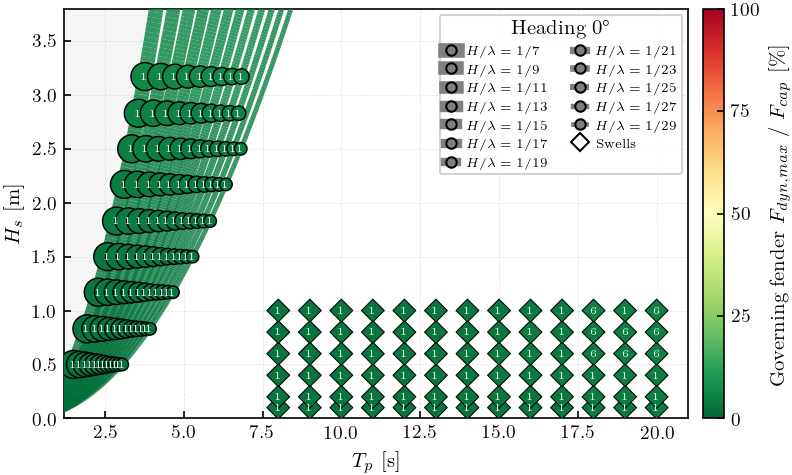

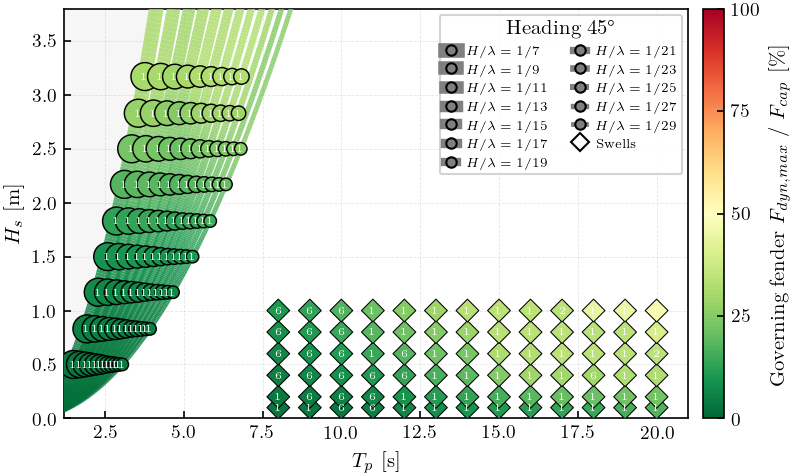

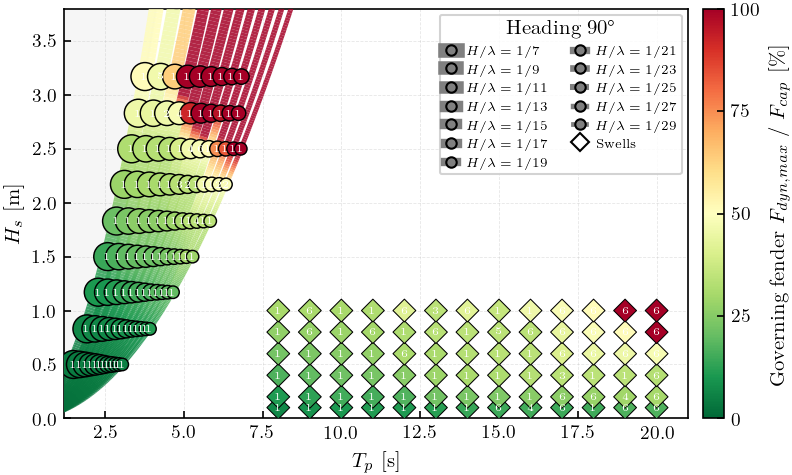

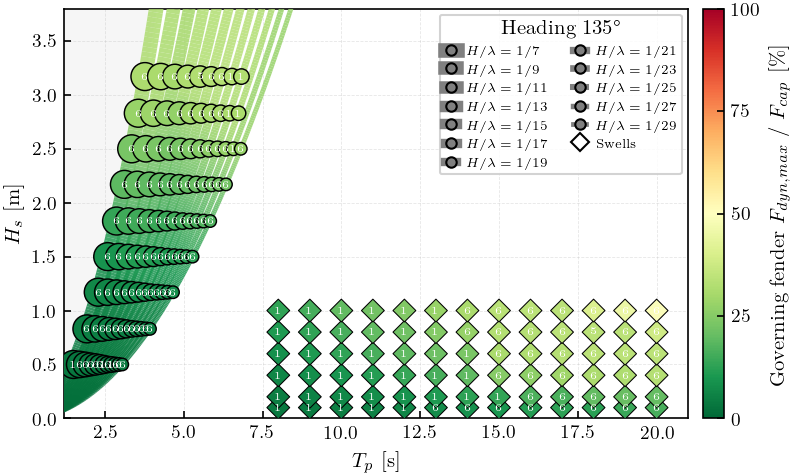

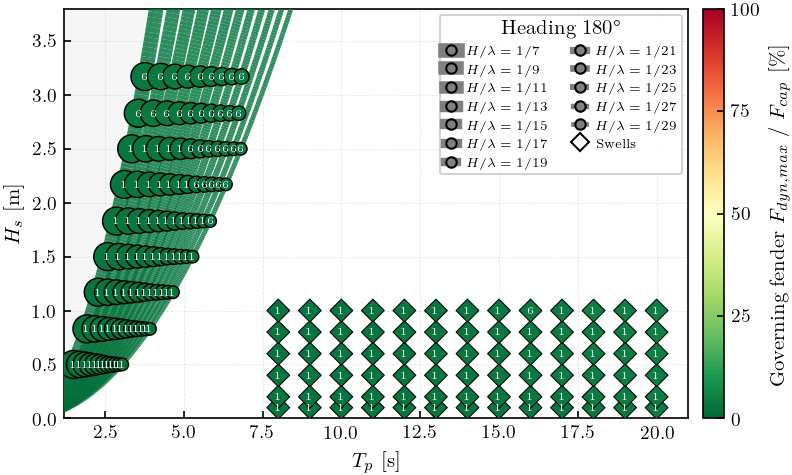

In [5]:
cmap = plt.cm.RdYlGn_r
norm = Normalize(vmin=VMIN, vmax=VMAX, clip=True)
sweep = np.linspace(0.3, 21, 800)

line_handles = [
    Line2D([0], [0], color='grey', lw=cfg['lw'], label=cfg['label'],
           marker='o', markerfacecolor='grey', markeredgecolor='black', markersize=5)
    for cfg in LINES.values()
]
swell_handle = Line2D([0], [0], linestyle='none', marker='D',
                      markerfacecolor='white', markeredgecolor='black',
                      markersize=6, label='Swells')

def make_lc(x, y, val_arr, lw):
    pts  = np.array([x, y]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap=cmap, norm=norm, linewidth=lw, alpha=0.85, zorder=3)
    lc.set_array((val_arr[:-1] + val_arr[1:]) / 2)
    return lc

for h in HEADINGS:
    sub_ww = ww[ww.heading == h]
    fig, ax = plt.subplots(figsize=full())
    ax.fill_between(sweep, g * sweep**2 / (2 * np.pi * 7), 10,
                    color='lightgrey', alpha=0.2, zorder=0)

    sc_ref = None
    for line_name, cfg in LINES.items():
        y_curve  = g * sweep**2 / (2 * np.pi * cfg['n'])
        sub      = sub_ww[sub_ww.line == line_name]
        val_dict = dict(zip(sub.cond_num, sub.pct_cap))
        num_dict = dict(zip(sub.cond_num, sub.gov_num))
        conds    = sorted(cfg['cond_params'])
        pts_x    = np.array([cfg['cond_params'][c][1] for c in conds])
        pts_y    = np.array([cfg['cond_params'][c][0] for c in conds])
        val_pts  = np.array([val_dict.get(c, np.nan) for c in conds])

        val_interp = np.interp(sweep,
                               np.concatenate([[sweep[0]], pts_x]),
                               np.concatenate([[0.0], val_pts]))
        ax.add_collection(make_lc(sweep, y_curve, val_interp, cfg['lw']))
        sc = ax.scatter(pts_x, pts_y, c=val_pts, cmap=cmap, norm=norm,
                        s=cfg['ms'], zorder=5, edgecolors='black', linewidths=0.7, marker='o')
        if sc_ref is None:
            sc_ref = sc
        for c, x, y in zip(conds, pts_x, pts_y):
            num = num_dict.get(c, '')
            if num:
                ax.text(x, y, num, ha='center', va='center',
                        fontsize=5, fontweight='bold', color='white', zorder=6)

    if h in swell_data:
        sw = swell_data[h]
        ax.scatter(sw['Tp'], sw['Hs'], c=sw['pct_cap'], cmap=cmap, norm=norm,
                   s=60, marker='D', edgecolors='black', linewidths=0.5, zorder=7)
        for _, row in sw.iterrows():
            if not np.isnan(row['max_force_kN']):
                ax.text(row['Tp'], row['Hs'], str(row['gov_num']), ha='center', va='center',
                        fontsize=5, fontweight='bold', color='white', zorder=8)

    ax.set_xlabel('$T_p$ [s]')
    ax.set_ylabel('$H_s$ [m]')
    ax.set_xlim(1.2, 21)
    ax.set_ylim(0.0, 3.8)
    ax.grid(True, alpha=0.3)
    ax.legend(handles=line_handles + [swell_handle], fontsize=6,
              loc='upper right', ncol=2, handlelength=1.0,
              borderaxespad=0.5, framealpha=0.85, title=f'Heading {HEADING_LABELS[h]}')
    cb = fig.colorbar(sc_ref, ax=ax, pad=0.02)
    cb.set_label(r'Governing fender $F_{dyn,max}$ / $F_{cap}$ [\%]')
    cb.set_ticks([0, 25, 50, 75, 100])
    plt.tight_layout()
    save(fig, f'fender_cap_util_{h}')
    plt.show()

## Heatmap — Wind Sea (governing fender / capacity)

Rows = wave-steepness line, columns = $H_s$. Colour = governing fender $F_{dyn,max}$ as a percentage
of the 5053 kN capacity, on the same 0–100% scale. Cells above 100% (the fender has bottomed out)
saturate red and show their true percentage. Each cell is annotated with the governing fender.

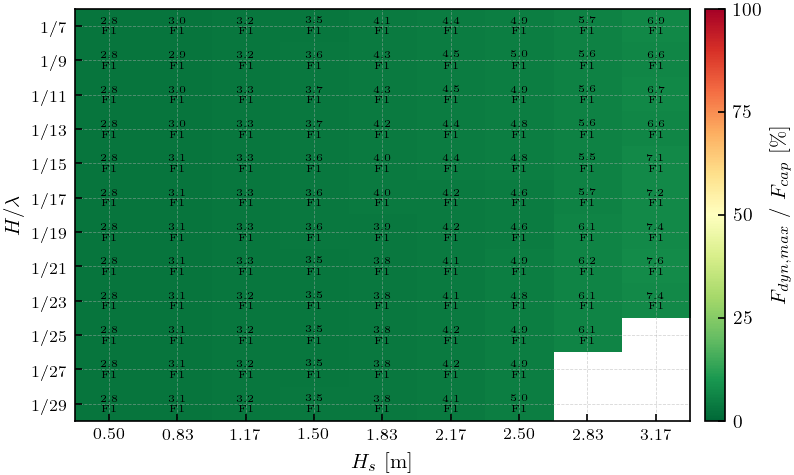

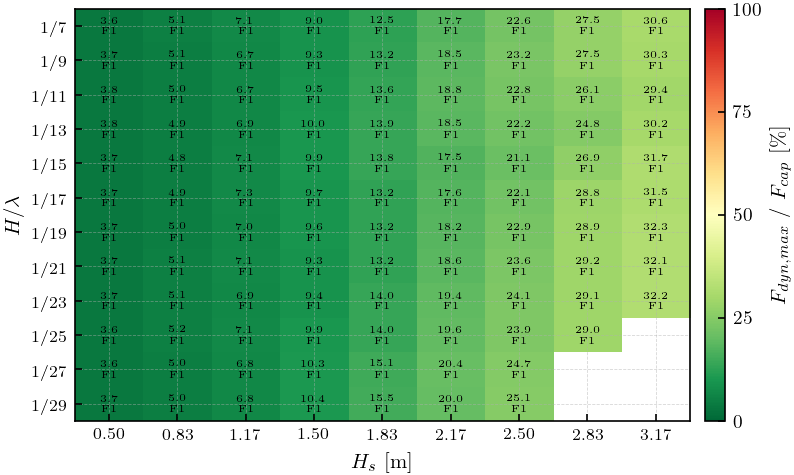

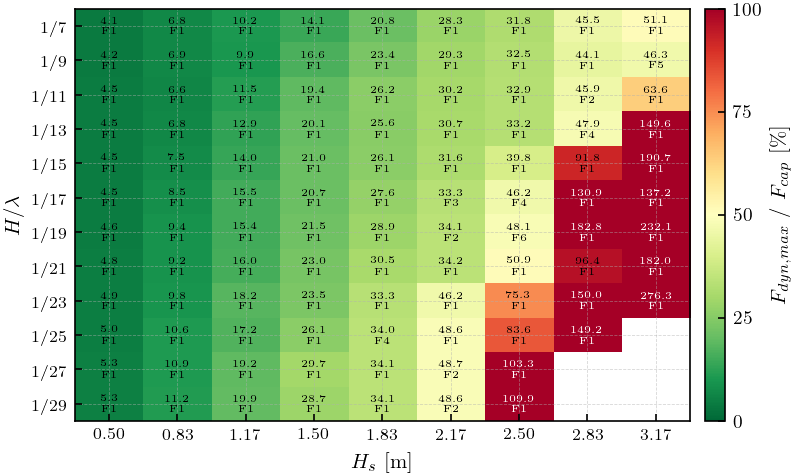

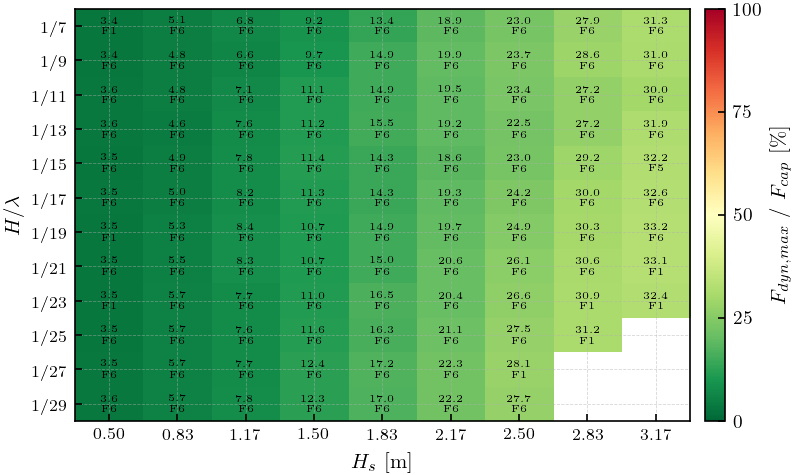

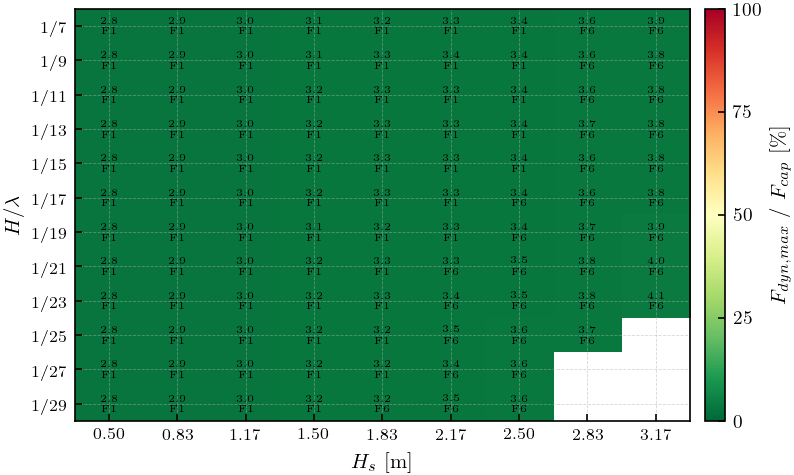

In [6]:
line_order = list(LINES.keys())
max_cond   = max(cfg['n_cond'] for cfg in LINES.values())

for h in HEADINGS:
    fig, ax = plt.subplots(figsize=full())
    sub_h = ww[ww.heading == h]
    mat = np.full((len(line_order), max_cond), np.nan)
    ann = np.full((len(line_order), max_cond), '', dtype=object)
    for r, ln in enumerate(line_order):
        for row in sub_h[sub_h.line == ln].itertuples():
            c = row.cond_num - 1
            if c < max_cond:
                mat[r, c] = row.pct_cap
                ann[r, c] = 'F' + str(row.gov_num)
    im = ax.imshow(mat, aspect='auto', vmin=VMIN, vmax=VMAX,
                   cmap=cmap, origin='upper', interpolation='none')
    ax.set_xticks(range(max_cond))
    ax.set_xticklabels([f'{HS_VALUES[i]:.2f}' for i in range(max_cond)], fontsize=8)
    ax.set_yticks(range(len(line_order)))
    ax.set_yticklabels(['$' + LINES[ln]['label'].split('= ')[1] for ln in line_order], fontsize=8)
    ax.set_xlabel('$H_s$ [m]')
    ax.set_ylabel('$H/\\lambda$')
    for r in range(len(line_order)):
        for c in range(max_cond):
            v = mat[r, c]
            if not np.isnan(v):
                ax.text(c, r, f'{v:.1f}%\n{ann[r, c]}', ha='center', va='center', fontsize=5,
                        color='white' if v > 100 else 'black')
    cb = fig.colorbar(im, ax=ax, pad=0.02)
    cb.set_label(r'$F_{dyn,max}$ / $F_{cap}$ [\%]')
    cb.set_ticks([0, 25, 50, 75, 100])
    plt.tight_layout()
    save(fig, f'fender_cap_util_heatmap_{h}')
    plt.show()

## Heatmap — Swells (governing fender / capacity)

Swell-only version on the long-period $H_s$–$T_p$ grid, same 0–100% scale for direct comparison with
the wind-sea heatmaps. Rows = $H_s$, columns = $T_p$; cells above 100% saturate red and keep their
true value. Annotated with the governing fender.

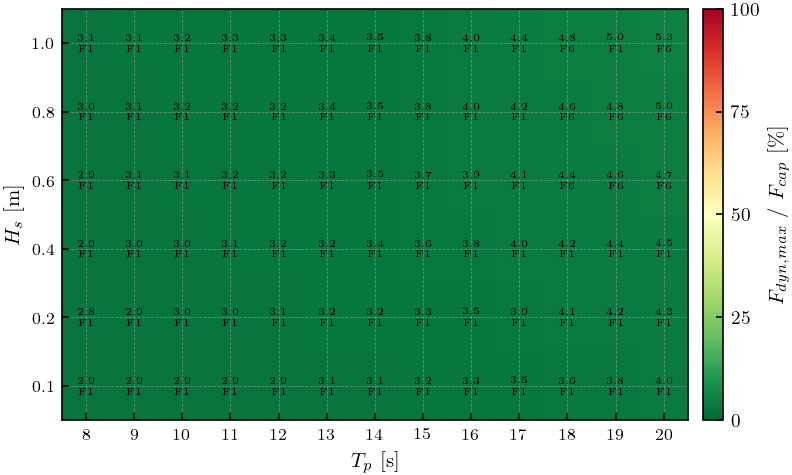

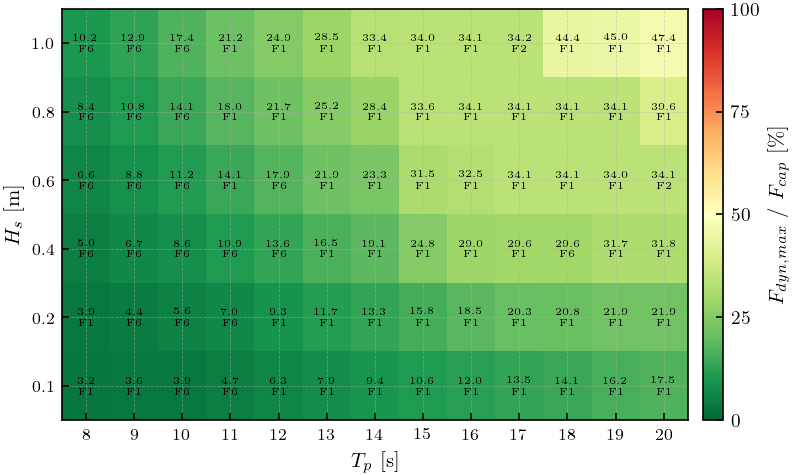

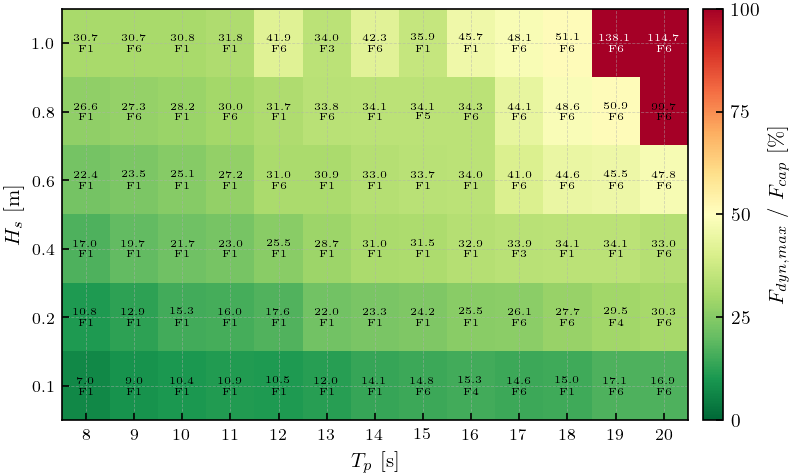

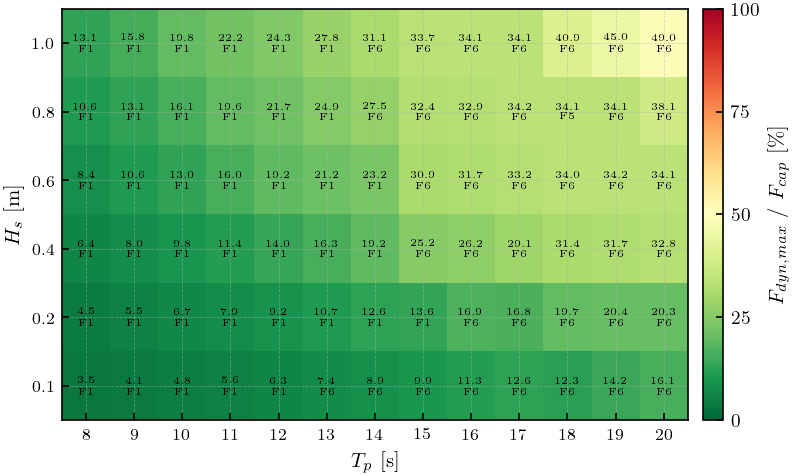

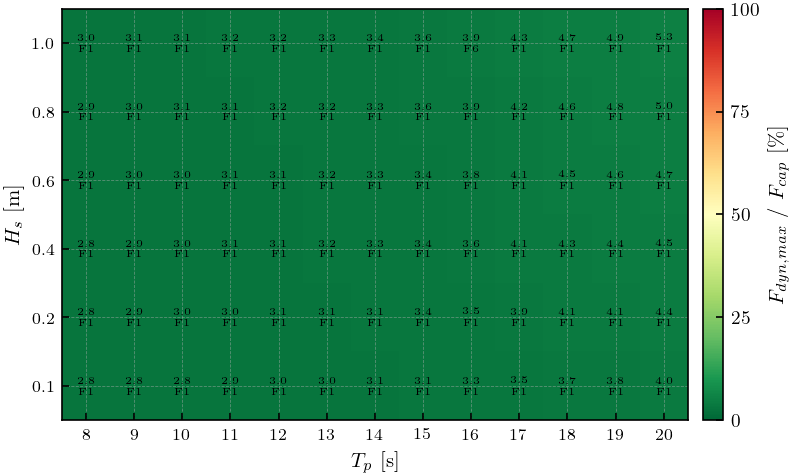

In [7]:
for h in available:
    sw  = swell_data[h]
    mat = np.full((len(HS_VALS), len(TP_VALS)), np.nan)
    ann = np.full((len(HS_VALS), len(TP_VALS)), '', dtype=object)
    for _, row in sw.iterrows():
        if pd.isna(row['Hs']) or pd.isna(row['Tp']) or pd.isna(row['pct_cap']):
            continue
        r = HS_VALS.index(row['Hs'])
        c = TP_VALS.index(int(row['Tp']))
        mat[r, c] = row['pct_cap']
        ann[r, c] = 'F' + str(row['gov_num'])

    fig, ax = plt.subplots(figsize=full())
    im = ax.imshow(mat, aspect='auto', vmin=VMIN, vmax=VMAX, cmap=cmap,
                   origin='lower', interpolation='none')
    ax.set_xticks(range(len(TP_VALS)))
    ax.set_xticklabels([str(t) for t in TP_VALS], fontsize=8)
    ax.set_yticks(range(len(HS_VALS)))
    ax.set_yticklabels([f'{hs:.1f}' for hs in HS_VALS], fontsize=8)
    ax.set_xlabel('$T_p$ [s]')
    ax.set_ylabel('$H_s$ [m]')
    for r in range(len(HS_VALS)):
        for c in range(len(TP_VALS)):
            v = mat[r, c]
            if not np.isnan(v):
                ax.text(c, r, f'{v:.1f}%\n{ann[r, c]}', ha='center', va='center', fontsize=5,
                        color='white' if v > 100 else 'black')
    cb = fig.colorbar(im, ax=ax, pad=0.02)
    cb.set_label(r'$F_{dyn,max}$ / $F_{cap}$ [\%]')
    cb.set_ticks([0, 25, 50, 75, 100])
    plt.tight_layout()
    save(fig, f'fender_cap_util_swell_heatmap_{h}')
    plt.show()